In [1]:
# 自动检查并安装依赖项
import importlib
import subprocess
import sys

def check_and_install(package):
    try:
        importlib.import_module(package)
        print(f"{package} 已安装")
    except ImportError:
        print(f"{package} 未安装，正在安装...")
        # 使用Popen代替check_call以支持实时输出
        process = subprocess.Popen(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1
        )
        
        # 实时读取并打印输出
        for line in iter(process.stdout.readline, ''):
            print(line.strip())
        
        process.stdout.close()
        process.wait()
        
        if process.returncode == 0:
            print(f"{package} 安装完成")
        else:
            print(f"{package} 安装失败，返回代码 {process.returncode}")

# 检查并安装必要的依赖项
required_packages = ['pandas', 'matplotlib', 'seaborn']
for package in required_packages:
    check_and_install(package)

pandas 已安装
matplotlib 已安装
seaborn 已安装


In [2]:
import re
import json
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Path to log file
log_file_path = '/root/autodl-fs/mimibot-factory/grpo_log_0322-4.txt'

# Read the log file
with open(log_file_path, 'r') as file:
    log_content = file.read()

log_list = []
# 逐行扫描
for line in log_content.split('\n'):
    # 匹配日志行的正则表达式
    """
    {'loss': 0.0254, 'grad_norm': 17.50685691833496, 'learning_rate': 9.992292139465165e-05, 'rewards/reward_format': 22.70833384990692, 'rewards/reward_no_repetition': 0.0, 'rewards/reward_similarity': 752.6263809204102, 'reward': 775.3347015380859, 'reward_std': 345.1836128234863, 'completion_length': 73.27083778381348, 'kl': 0.6342208124697208, 'epoch': 0.18}
    """
    match = re.search(r"{'loss': (.*?)}", line)
    if match:
        match_line = match.group(0).replace('\'', '\"')
        # 加载为字典
        log_dict = json.loads(match_line)
        log_list.append(log_dict)
# print(log_list)

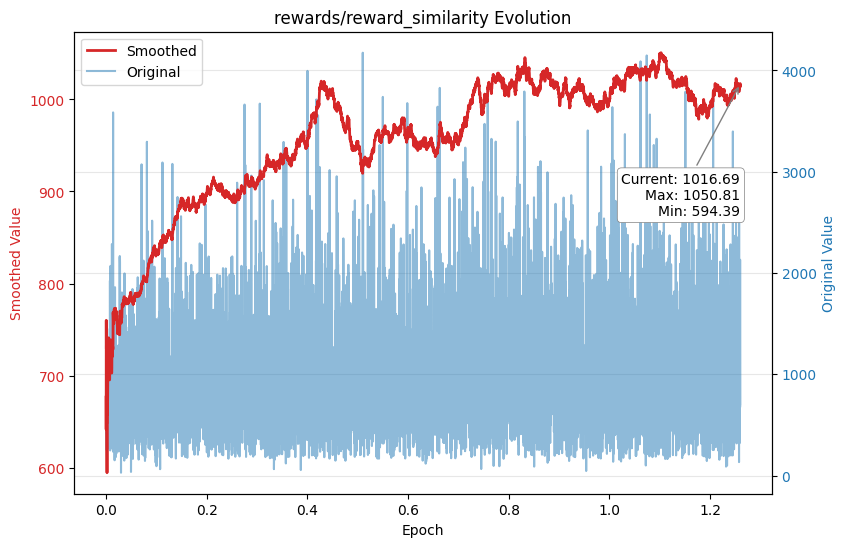

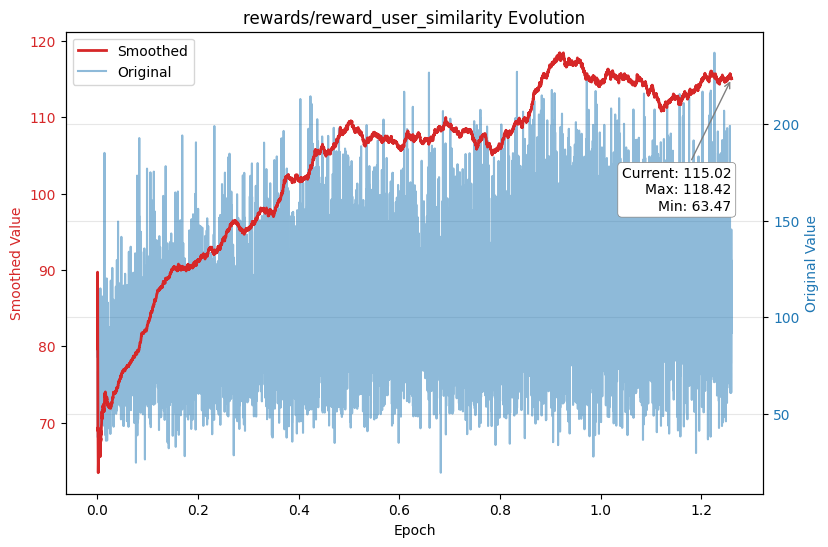

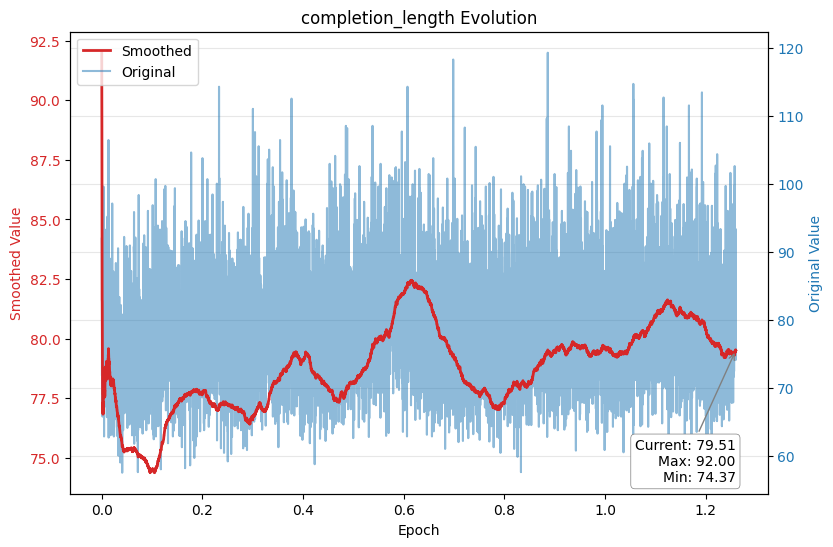

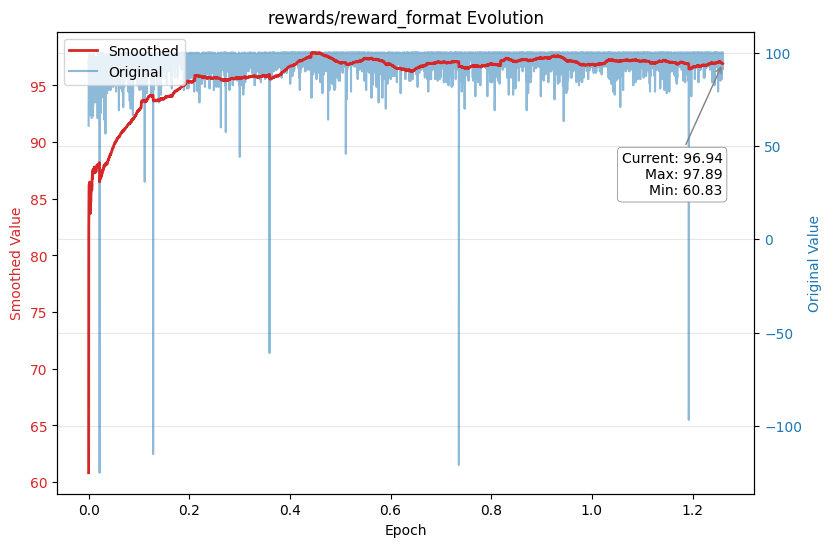

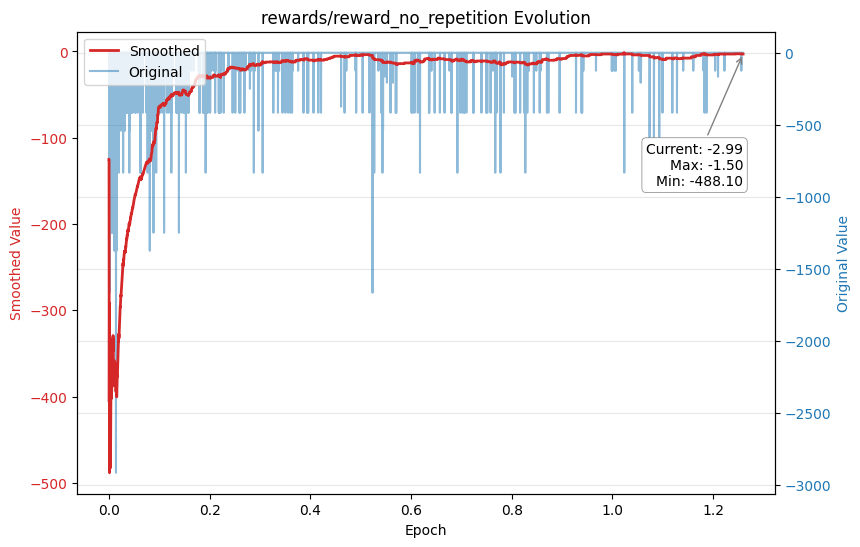

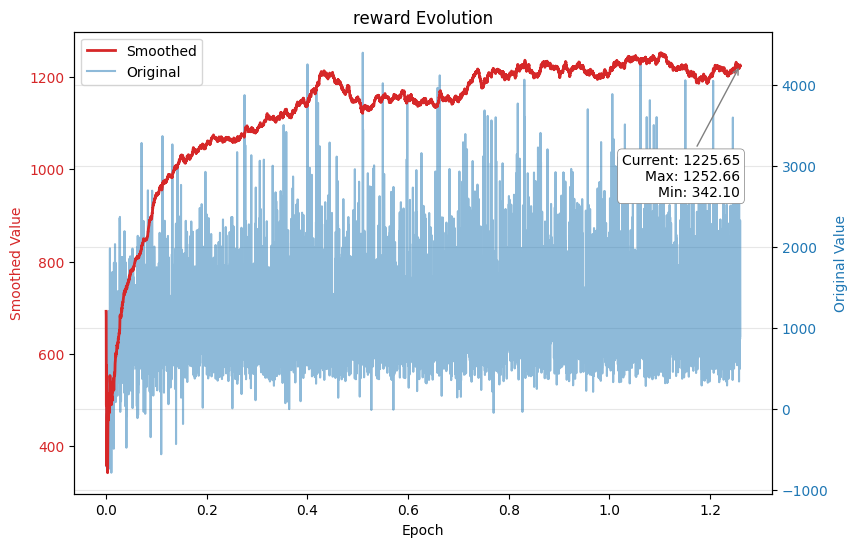

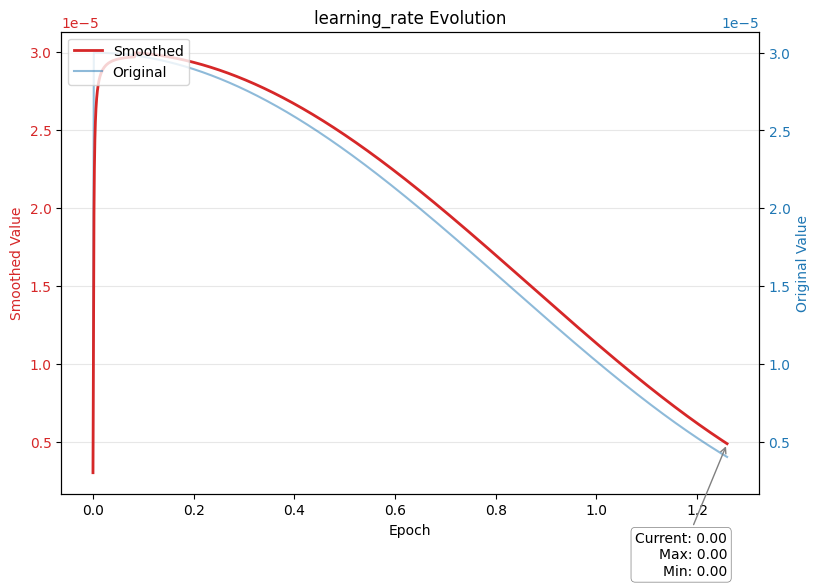

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 提取epoch数据和需要绘制的所有指标
epoch_list = [log['epoch'] for log in log_list]

metrics = [
    'rewards/reward_similarity',
    'rewards/reward_user_similarity',
    'completion_length',
    'rewards/reward_format',
    'rewards/reward_no_repetition',
    'reward',
    'learning_rate'
]

step_list = [i for i in range(len(epoch_list))]
epoch_list = [i/len(step_list) * max(epoch_list) for i in step_list]

# 创建数据字典存储所有指标数据
data = {metric: [log[metric] for log in log_list] for metric in metrics}

# 定义数据平滑函数
def smooth_data(data, window_size=1000):
    """使用移动平均平滑数据"""
    return [sum(data[max(0, i-window_size):i+1])/len(data[max(0, i-window_size):i+1]) 
            for i in range(len(data))]

def smooth_bounds(data, window_size=200):
    """计算移动窗口的最大最小值"""
    upper, lower = [], []
    for i in range(len(data)):
        window = data[max(0, i-window_size):i+1]
        upper.append(max(window))
        lower.append(min(window))
    return upper, lower

# 为每个指标创建独立图表
for metric in metrics:
    fig, ax1 = plt.subplots(figsize=(9, 6))  # 增大画布尺寸
    ax2 = ax1.twinx()

    # 绘制原始数据（左轴）
    color_original = 'tab:blue'
    ax1.set_xlabel('Epoch')
    ax2.set_ylabel('Original Value', color=color_original)
    ax2.tick_params(axis='y', labelcolor=color_original)
    
    # 创建右轴绘制平滑数据
    color_smoothed = 'tab:red'
    ax1.set_ylabel('Smoothed Value', color=color_smoothed)
    
    # 计算数据
    smoothed = smooth_data(data[metric])
    upper, lower = smooth_bounds(data[metric])
    last_value = smoothed[-1]
    
    # 绘制三条趋势线
    ax1.plot(epoch_list, smoothed, color=color_smoothed, 
             linewidth=2, linestyle='-', label='Smoothed')
    # ax2.plot(epoch_list, upper, color='darkorange', 
    #          linewidth=1, linestyle='--', label='Upper Bound')
    # ax2.plot(epoch_list, lower, color='green', 
    #          linewidth=1, linestyle=':', label='Lower Bound')
    
    # 标注最终数值
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.5)
    ax1.annotate(f'Current: {last_value:.2f}\nMax: {max(smoothed):.2f}\nMin: {min(smoothed):.2f}',
                xy=(epoch_list[-1], last_value),
                xytext=(0, -80), textcoords='offset points',
                bbox=bbox_props,
                ha='right', va='center',
                arrowprops=dict(arrowstyle="->", color='gray'))
    ax2.plot(epoch_list, data[metric], color=color_original, alpha=0.5, label='Original')

    ax1.tick_params(axis='y', labelcolor=color_smoothed)
    ax1.set_zorder(ax2.get_zorder() + 1)  # 确保ax1在ax2上层
    ax1.patch.set_visible(False)  # 隐藏ax1的背景
    # 合并图例并添加标题
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')
    plt.title(f'{metric} Evolution')
    plt.grid(True, alpha=0.3)
    
    # 自动调整坐标轴范围
    # ax2.set_ylim(min(lower)*0.95, max(upper)*1.05)

plt.show()